## Reinforcement Learning. Q-algorithm. Federated Learning
### В данном ноутбуке представлена реализация алгоритма Q-learning машинного обучения с подкреплением
### Цель - обучение агента федеративным методом достижению цели на поле 8x8

#### Импорт библиотек. Разработка функций для обучения

In [1]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
from typing import List
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import Image, display, HTML

# Параметры
num_states = 8*8 * 8*8 # Количество состояний
num_actions = 4  # Количество действий

In [2]:
# Функция для получения индекса состояния в Q-таблице
def get_index(state: List[int]) -> int:
    return 64 * (state[0] + 8 * state[1]) + state[2] + 8 * state[3]

# Функция для получения координат цели и агента из индекса состояния
def get_state(ind: int) -> List[int]:
    x_a = ind // 64 % 8
    y_a = ind // 64 // 8
    x_t = ind % 64 % 8
    y_t = ind % 64 // 8
    return [x_a, y_a, x_t, y_t]

# Расчет манхэттенского расстояния
def get_distance(a_coord: List[int], t_coord: List[int]) -> int:
    return abs(a_coord[0] - t_coord[0]) + abs(a_coord[1] - t_coord[1])

In [3]:
# Обучение
def q_learning(Q_table:np.ndarray, Q_update:int, episodes:int, epsilon:float, alpha:float = 0.1):
    info = [[], [], []]
    states = []

    for i in range(episodes):
        index = np.random.randint(num_states)  # Случайное начальное состояние
        state = get_state(index) # Координаты цели и агента
        n_steps = 0

        # Запись данных по итерации обучения
        info[0].append(i)
        info[1].append(get_distance(state[0:2], state[2:4]))

        # Запись изначального состояния итерации для отображения
        states.append(state)

        while state[0:2] != state[2:4]:  # Цикл до достижения агентом цели
            # Определение текущего расстояния до цели
            distance = get_distance(state[0:2], state[2:4])
            
            # Выбор действия
            if np.random.rand() < epsilon:
                action = np.random.randint(num_actions)  # Исследование
            else:
                action = np.argmax(Q[index])  # Эксплуатация
            
            # Определение нового состояния
            if action == 0:
                if state[1] + 1 > 7: continue
                else: state[1] += 1
            elif action == 1:
                if state[0] + 1 > 7: continue
                else: state[0] += 1
            elif action == 2:
                if state[1] - 1 < 0: continue
                else: state[1] -= 1
            elif action == 3:
                if state[0] - 1 < 0: continue
                else: state[0] -= 1

            # Определение награды
            reward = (distance - get_distance(state[0:2], state[2:4])) / distance
            
            # Обновление Q-значения
            if Q_update == 1:
                Q_table[index, action] += alpha * (reward + np.max(Q[get_index(state)]) - Q[index, action])
            
            # Переход к следующему состоянию
            index = get_index(state)

            # Подсчет шагов
            n_steps += 1

            # Запись состояний для отображения
            states.append(state.copy())
        
        # Запись данных шагов по итерации обучения о количестве сделанных шагов
        info[2].append(n_steps)
    
    df = pd.DataFrame({
        'id': info[0],
        'distance': info[1],
        'steps': info[2]
    })
    df['steps/distance'] = df['steps'] / df['distance']

    return Q_update, df, states

#### Обучение 3-x агентов на 30000 итерациях с параметрами epsilon = 0.01 и alpha = 0.2. Создание Q-таблицы с усредненными значениями наград и сбор информации по эффективности достижения цели федеративным агентом

In [4]:
# Инициализация Q-таблицы с нулевыми значениями наград
Q = np.zeros((num_states, num_actions))

# Обучение 3-х агентов
Q_1, df1, states1 = q_learning(Q, 1, 30000, 0.01, 0.2)
Q_2, _, _ = q_learning(Q, 1, 30000, 0.01, 0.2)
Q_3, _, _ = q_learning(Q, 1, 30000, 0.01, 0.2)

# Сбор информации по эффективности достижения цели агентами 2 и 3
_, df2, states2 = q_learning(Q_2, 0, 1000, 0)
_, df3, states3 = q_learning(Q_3, 0, 1000, 0)


# Усреднение результатов и сбор информации по эффективности достижения цели федеративным агентом
Q_federated = np.mean([Q_1, Q_2, Q_3], axis = 0)
_, df_fed, states_fed = q_learning(Q_federated, 0, 1000, 0)

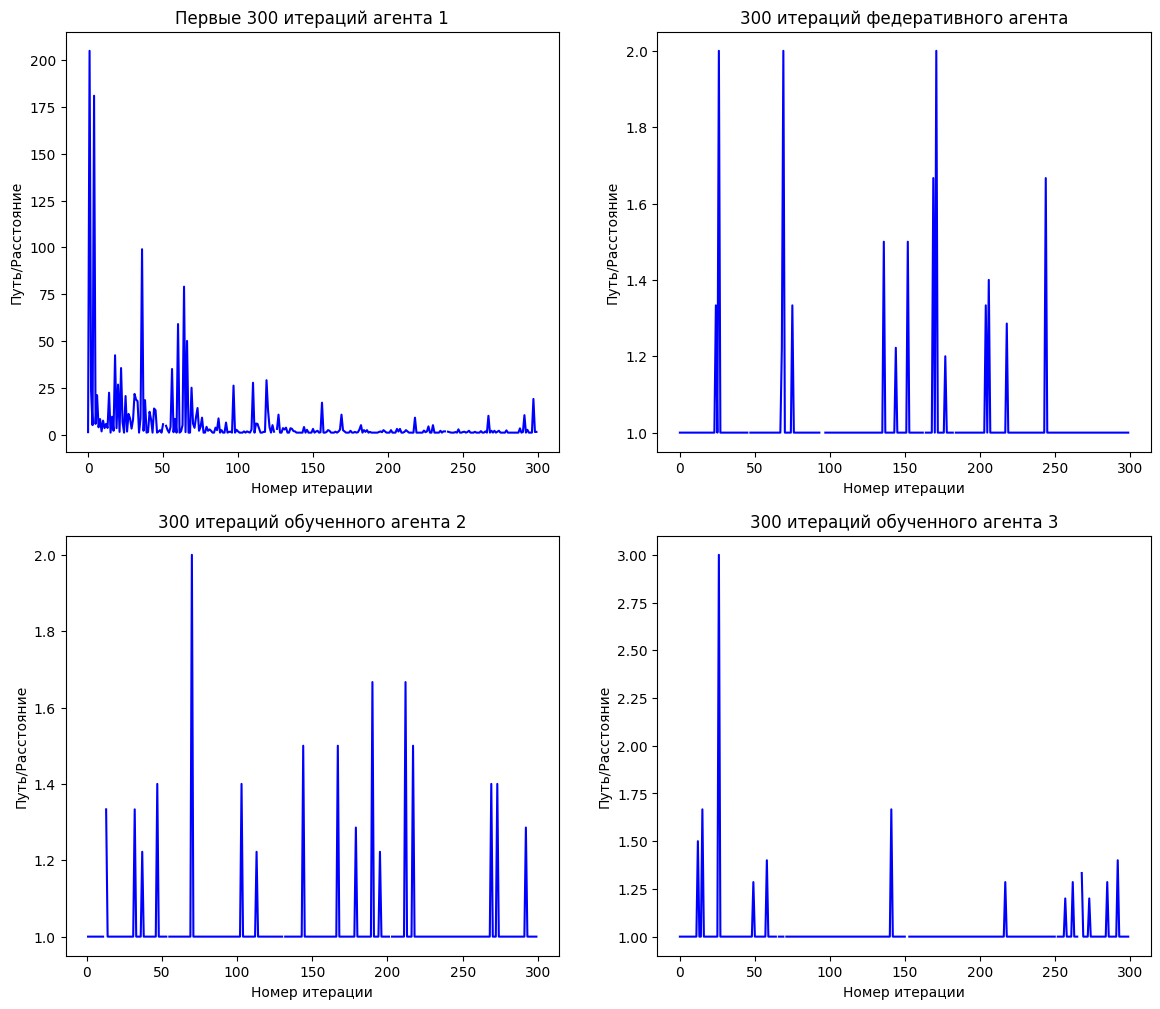

In [5]:
# Инициализация подграфиков
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Создание первого графика
axs[0][0].plot(df1['id'].head(300), df1['steps/distance'].head(300), 'b-')
axs[0][0].set_title('Первые 300 итераций агента 1')
axs[0][0].set_xlabel('Номер итерации')
axs[0][0].set_ylabel('Путь/Расстояние')

# Создание второго графика
axs[0][1].plot(df_fed['id'].head(300), df_fed['steps/distance'].head(300), 'b-')
axs[0][1].set_title('300 итераций федеративного агента')
axs[0][1].set_xlabel('Номер итерации')
axs[0][1].set_ylabel('Путь/Расстояние')

# Создание третьего графика
axs[1][0].plot(df2['id'].head(300), df2['steps/distance'].head(300), 'b-')
axs[1][0].set_title('300 итераций обученного агента 2')
axs[1][0].set_xlabel('Номер итерации')
axs[1][0].set_ylabel('Путь/Расстояние')

# Создание четвертого графика
axs[1][1].plot(df3['id'].head(300), df3['steps/distance'].head(300), 'b-')
axs[1][1].set_title('300 итераций обученного агента 3')
axs[1][1].set_xlabel('Номер итерации')
axs[1][1].set_ylabel('Путь/Расстояние')

# Показать графики
plt.show()

#### Запись перемещений агентов в gif-файлы для иллюстрации эффективности обучения

In [6]:
# Инициализация графика
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(0, 8)
ax.set_ylim(0, 8)
ax.set_xticks(range(9))
ax.set_yticks(range(9))
ax.grid(True)

# Создаем точки для агента и цели
agent_dot, = ax.plot([], [], 'bo', label='Агент')
target_dot, = ax.plot([], [], 'ro', label='Цель')

# Настройка легенды
ax.legend()

# Функция инициализации
def init():
    agent_dot.set_data([], [])
    target_dot.set_data([], [])
    return agent_dot, target_dot

# Функция обновления для анимации
def update(frame):
    x_agent, y_agent, x_target, y_target = states1[:1000][frame]
    
    agent_dot.set_data(x_agent, y_agent)
    target_dot.set_data(x_target, y_target)
    
    return agent_dot, target_dot

# Создание анимации
ani = FuncAnimation(fig, update, frames=len(states1[:1000]), init_func=init, blit=True, repeat=False)

# Сохранение анимации в формате GIF с использованием Pillow
ani.save('first_1000_steps_agent1.gif', writer='pillow', fps=4)
plt.close(fig)

In [7]:
# Инициализация графика
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(0, 8)
ax.set_ylim(0, 8)
ax.set_xticks(range(9))
ax.set_yticks(range(9))
ax.grid(True)

# Создаем точки для агента и цели
agent_dot, = ax.plot([], [], 'bo', label='Агент')
target_dot, = ax.plot([], [], 'ro', label='Цель')

# Настройка легенды
ax.legend()

# Функция инициализации
def init():
    agent_dot.set_data([], [])
    target_dot.set_data([], [])
    return agent_dot, target_dot

# Функция обновления для анимации
def update(frame):
    x_agent, y_agent, x_target, y_target = states_fed[:1000][frame]
    
    agent_dot.set_data(x_agent, y_agent)
    target_dot.set_data(x_target, y_target)
    
    return agent_dot, target_dot

# Создание анимации
ani = FuncAnimation(fig, update, frames=len(states_fed[:1000]), init_func=init, blit=True, repeat=False)

# Сохранение анимации в формате GIF с использованием Pillow
ani.save('1000_steps_fed_agent.gif', writer='pillow', fps=4)
plt.close(fig)

#### Иллюстрация результатов обучения

In [8]:
# Создание HTML-кода для отображения GIF
html_code = f"""
<div style="display: flex; justify-content: space-around; align-items: center;">
    <div style="text-align: center;">
        <h3>Первые 1000 шагов агента 1</h3>
        <img src="first_1000_steps_agent1.gif" alt="GIF 1" style="width: 700px; height: auto;"/>
    </div>
    <div style="text-align: center;">
        <h3>1000 шагов федеративного агента</h3>
        <img src="1000_steps_fed_agent.gif" alt="GIF 2" style="width: 700px; height: auto;"/>
    </div>
</div>
"""

# Отображение
display(HTML(html_code))

#### По окончании обучения можно сделать вывод, что в случае машинного обучения с подкреплением, реализованного с помощью алгоритма Q-learning, использование федеративного метода не оправдано, так как не ведет к заметному увеличению эффектиновсти обучения